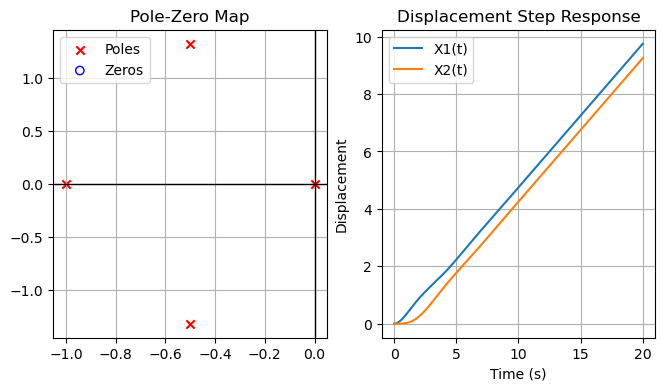

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# Define system parameters
M1, M2, B1, B2, K = 1, 1, 1, 1, 1

# Define denominator and numerator coefficients
den = [M1*M2, (B1*M2 + B2*M1), (B1*B2 + K*M1 + K*M2), (B1*K + B2*K), 0]
num1 = [M2, B2, K]
num2 = [K]

# Create Transfer Function objects
H1 = signal.TransferFunction(num1, den)
H2 = signal.TransferFunction(num2, den)

# Velocity Transfer Function Hv2(s) = s * H2(s)
num_v2 = [K]
den_v2 = den[:-1]
Hv2 = signal.TransferFunction(num_v2, den_v2)

# Time vector for simulation
t = np.linspace(0, 20, 1000)

# 1. Pole-Zero Map
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
poles = H2.poles
zeros = H2.zeros
plt.scatter(np.real(poles), np.imag(poles), marker='x', color='red', label='Poles')
plt.scatter(np.real(zeros), np.imag(zeros), marker='o', facecolors='none', edgecolors='blue', label='Zeros')
plt.axhline(0, color='black', lw=1)
plt.axvline(0, color='black', lw=1)
plt.title('Pole-Zero Map')
plt.grid(True)
plt.legend()

# 2. Displacement Step Response
t1, x1 = signal.step(H1, T=t)
t2, x2 = signal.step(H2, T=t)
plt.subplot(1, 3, 2)
plt.plot(t1, x1, label='X1(t)')
plt.plot(t2, x2, label='X2(t)')
plt.title('Displacement Step Response')
plt.xlabel('Time (s)')
plt.ylabel('Displacement')
plt.legend()
plt.grid(True)

